# Check combined 2025 data with frequency

This notebook loads the merged 2025 dataset and makes a few quick plots to verify that the frequency columns line up with the hourly community data.

In [3]:
import pandas as pd

data_path = "../data_out/combined_2025_with_frequency.csv"
df = pd.read_csv(data_path)
df.head()

,hour_utc,ec_id,unique_id,consumption,pv_production_kwh,spot_exkl_vat_ore_kwh,buy_price_inkl_vat_ore_kwh,sell_price_inkl_vat_ore_kwh,price_ore_kwh_fcr_d_ned__d_1_early,price_ore_kwh_fcr_d_ned__d_1_late,...,wind_forecast,relative_hum_forecast,precip_forecast,timestamp_utc,freq_avg_hz,y_act_fcrd_up,y_act_fcrd_down,y_act_fcrn_up,y_act_fcrn_down,data_quality_flag
0,2025-01-01 00:00:00+00:00,b,dk2_community_01,0.0,0.0,1.439,28.99875,0.849,5.96800,2.984,...,37.4,91,0.6,2025-01-01 00:00:00,50.020262,0.0,0.000512,0.065261,0.265833,0
1,2025-01-01 00:00:00+00:00,s,dk2_community_01,0.0,0.0,1.439,28.99875,0.849,5.96800,2.984,...,37.4,91,0.6,2025-01-01 00:00:00,50.020262,0.0,0.000512,0.065261,0.265833,0
2,2025-01-01 01:00:00+00:00,b,dk2_community_01,5.5,0.0,1.439,28.99875,0.849,7.51968,1.119,...,36.4,90,1.0,2025-01-01 01:00:00,49.980895,0.0,0.000000,0.203041,0.011990,0
3,2025-01-01 01:00:00+00:00,s,dk2_community_01,7.6,0.0,1.439,28.99875,0.849,7.51968,1.119,...,36.4,90,1.0,2025-01-01 01:00:00,49.980895,0.0,0.000000,0.203041,0.011990,0
4,2025-01-01 02:00:00+00:00,b,dk2_community_01,7.9,0.0,1.066,28.53250,0.476,7.38540,1.119,...,36.0,90,0.9,2025-01-01 02:00:00,49.991883,0.0,0.000000,0.155282,0.074107,0


In [7]:
df.columns

Index(['hour_utc', 'ec_id', 'unique_id', 'consumption', 'pv_production_kwh',
       'spot_exkl_vat_ore_kwh', 'buy_price_inkl_vat_ore_kwh',
       'sell_price_inkl_vat_ore_kwh', 'price_ore_kwh_fcr_d_ned__d_1_early',
       'price_ore_kwh_fcr_d_ned__d_1_late', 'price_ore_kwh_fcr_d_ned__total',
       'price_ore_kwh_fcr_d_upp__d_1_early',
       'price_ore_kwh_fcr_d_upp__d_1_late', 'price_ore_kwh_fcr_d_upp__total',
       'price_ore_kwh_fcr_n__d_1_early', 'price_ore_kwh_fcr_n__d_1_late',
       'price_ore_kwh_fcr_n__total', 'mean_temp', 'mean_radiation',
       'mean_wind_speed', 'mean_relative_hum', 'acc_precip', 'temp_forecast',
       'solar_forecast', 'wind_forecast', 'relative_hum_forecast',
       'precip_forecast', 'timestamp_utc', 'freq_avg_hz', 'y_act_fcrd_up',
       'y_act_fcrd_down', 'y_act_fcrn_up', 'y_act_fcrn_down',
       'data_quality_flag'],
      dtype='str')

                    hour_utc  freq_avg_hz
0  2025-08-01 00:00:00+00:00    50.004934
1  2025-08-01 01:00:00+00:00    50.000315
2  2025-08-01 02:00:00+00:00    50.006950
3  2025-08-01 03:00:00+00:00    49.994994
4  2025-08-01 04:00:00+00:00    49.998498
5  2025-08-01 05:00:00+00:00    49.998881
6  2025-08-01 06:00:00+00:00    49.995751
7  2025-08-01 07:00:00+00:00    50.010532
8  2025-08-01 08:00:00+00:00    49.998346
9  2025-08-01 09:00:00+00:00    49.997993
10 2025-08-01 10:00:00+00:00    50.021129
11 2025-08-01 11:00:00+00:00    49.994529
12 2025-08-01 12:00:00+00:00    49.995341
13 2025-08-01 13:00:00+00:00    49.998882
14 2025-08-01 14:00:00+00:00    50.007416
15 2025-08-01 15:00:00+00:00    50.013859
16 2025-08-01 16:00:00+00:00    49.983523
17 2025-08-01 17:00:00+00:00    50.011895
18 2025-08-01 18:00:00+00:00    50.022575
19 2025-08-01 19:00:00+00:00    49.995740
20 2025-08-01 20:00:00+00:00    50.000120
21 2025-08-01 21:00:00+00:00    50.022167
22 2025-08-01 22:00:00+00:00    49

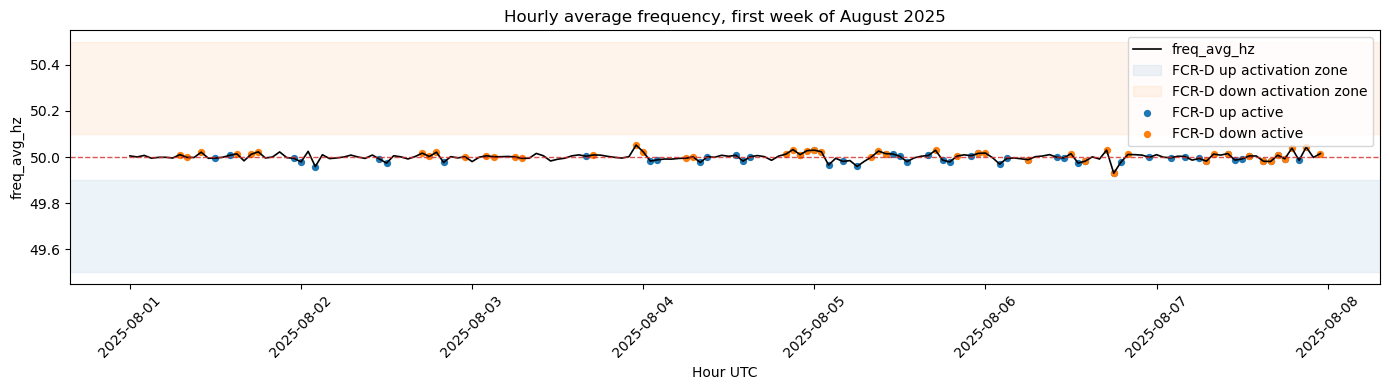

In [9]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Load the merged CSV from the same folder as this notebook.
data_path = Path("../data_out/combined_2025_with_frequency.csv")
df = pd.read_csv(data_path)
df["hour_utc"] = pd.to_datetime(df["hour_utc"], utc=True)
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

# First week of August 2025.
week_start = pd.Timestamp("2025-08-01", tz="UTC")
week_end = pd.Timestamp("2025-08-08", tz="UTC")
week = df[(df["hour_utc"] >= week_start) & (df["hour_utc"] < week_end)].copy()

# Collapse the two rows per hour to one hourly value before plotting.
hourly = week.groupby("hour_utc", as_index=False).agg({
    "freq_avg_hz": "mean",
    "y_act_fcrd_up": "mean",
    "y_act_fcrd_down": "mean",
    "y_act_fcrn_up": "mean",
    "y_act_fcrn_down": "mean",
})

print(hourly[["hour_utc", "freq_avg_hz"]].head(24))

fcrd_up_active = hourly[hourly["y_act_fcrd_up"] > 0]
fcrd_down_active = hourly[hourly["y_act_fcrd_down"] > 0]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hourly["hour_utc"], hourly["freq_avg_hz"], color="black", linewidth=1.2, label="freq_avg_hz")
ax.axhline(50.0, color="tab:red", linestyle="--", linewidth=1, alpha=0.8)
ax.axhspan(49.5, 49.9, color="tab:blue", alpha=0.08, label="FCR-D up activation zone")
ax.axhspan(50.1, 50.5, color="tab:orange", alpha=0.08, label="FCR-D down activation zone")
ax.scatter(fcrd_up_active["hour_utc"], fcrd_up_active["freq_avg_hz"], color="tab:blue", s=18, label="FCR-D up active")
ax.scatter(fcrd_down_active["hour_utc"], fcrd_down_active["freq_avg_hz"], color="tab:orange", s=18, label="FCR-D down active")
ax.set_title("Hourly average frequency, first week of August 2025")
ax.set_xlabel("Hour UTC")
ax.set_ylabel("freq_avg_hz")
ax.legend(loc="best")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# same as above but mark in teh graph where fcrd up and down is activated